---
title: "Combining Colors: A Visual Guide to Sampling (NB)"
navtitle: "Combining Colors (NB)"
subtitle: "How different sampling methods shape outcomes"
description: "How different sampling methods shape outcomes."
format:
  html:
    page-layout: full
    title-block-banner: true
---

This notebook contains the code used to generate the sampling visualizations shown on the site.
It is intended for exploration and modification rather than step-by-step instruction.

In [1]:
import math
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# User Configuration

Parameters in this section can be modified to explore different sampling behaviors.

In [2]:
RANDOM_STATE = 42

In [3]:
counts = {
    "Red": 25,
    "Green": 25,
    "Blue": 25
}

In [4]:
color_map = {
    "Grey": "rgb(165, 165, 165)",
    "Red": "rgb(255, 0, 0)",
    "Green": "rgb(0, 180, 0)",
    "Blue": "rgb(0, 0, 255)"
}

In [5]:
sampling_config = {
    # --- Deterministic selection ---
    "Deterministic selection 100%": {
        "frac": 1.0,
        "is_subset": True,
        "replace": False
    },
    "Deterministic selection 50%": {
        "frac": 0.5,
        "is_subset": True,
        "replace": False
    },
    "Deterministic selection 25%": {
        "frac": .25,
        "is_subset": True,
        "replace": False
    },
    # --- Random selection (no replacement) ---
    "Random selection no replacement 100%": {
        "frac": 1.0,
        "is_subset": False,
        "replace": False
    },

    "Random selection no replacement 50%": {
        "frac": 0.5,
        "is_subset": False,
        "replace": False
    },
    "Random selection no replacement 25%": {
        "frac": .25,
        "is_subset": False,
        "replace": False
    },
    
    # --- Random selection (with replacement) ---
    "Random selection with replacement 100%": {
        "frac": 1.0,
        "is_subset": False,
        "replace": True
    },
    "Random selection with replacement 50%": {
        "frac": 0.5,
        "is_subset": False,
        "replace": True
    },
    "Random selection with replacement 25%": {
        "frac": .25,
        "is_subset": False,
        "replace": True
    },
}

In [6]:
SUBPLOT_PARAMS = {
    "rows": 3,
    "cols": 3,
    "horizontal_spacing": 0.02,
    "vertical_spacing": 0.08
}

In [7]:
plot_grid = [
    [
        "deterministic_selection_100",
        "random_selection_no_replacement_100",
        "random_selection_with_replacement_100",
    ],
    [
        "deterministic_selection_50",
        "random_selection_no_replacement_50",        
        "random_selection_with_replacement_50",
    ],
    [
        "deterministic_selection_25",
        "random_selection_no_replacement_25",
        "random_selection_with_replacement_25",
    ]
]

In [8]:
column_titles = [
    "DETERMINISTIC",
    "RANDOM<br>NO REPLACEMENT",
    "RANDOM<br>REPLACEMENT",
]
row_titles = ["100%", "50%", "25%"]

In [9]:
max_visible = 4  # cap for opacity scaling

# Functions

## Data Creation and Sampling

In [10]:
def make_population_df(
    counts: dict,
    x_centers: dict = None,
    x_jitter: float = 0.08,
    y_jitter: float = 0.6,
    seed: int = 42
) -> pd.DataFrame:
    """
    Create a population DataFrame where each row represents a single sample.

    Columns:
    - color: category label
    - color_index: unique index within each color (0-based)
    - global_index: unique index across entire population
    - x, y: fixed spatial coordinates for visualization
    """
    rng = np.random.default_rng(seed)

    if x_centers is None:
        x_centers = {
            "Red": -.5,
            "Green": 0.0,
            "Blue": .5
        }

    rows = []

    for color, n in counts.items():
        for i in range(n):
            rows.append({
                "color": color,
                "color_index": i,
                "x": x_centers[color] + rng.normal(0, x_jitter),
                "y": rng.normal(0, y_jitter)
            })

    df = pd.DataFrame(rows)
    df["global_index"] = range(len(df))

    return df

In [11]:
def compute_draw_count(
    df_population: pd.DataFrame,
    frac: float,
    is_subset: bool,
    replace: bool,
    random_state: int | None = None
) -> pd.Series:
    """
    Compute per-sample draw counts for a given sampling configuration.

    Returns
    -------
    pd.Series
        Integer draw counts indexed like df_population.
    """
    n_total = int(len(df_population) * frac)

    # Initialize all counts to zero
    draw_count = pd.Series(0, index=df_population.index)

    if is_subset:
        # Deterministic: per-color proportional truncation
        cutoffs = (
            df_population.groupby("color")["color_index"]
            .max()
            .add(1)
            .mul(frac)
            .apply(np.ceil)
            .astype(int)
        )

        selected_idx = df_population.index[
            df_population["color_index"] < df_population["color"].map(cutoffs)
        ]

        draw_count.loc[selected_idx] = 1

    else:
        # Random sampling (with or without replacement)
        sampled_idx = df_population.sample(
            n=n_total,
            replace=replace,
            random_state=random_state
        ).index

        counts = sampled_idx.value_counts()
        draw_count.loc[counts.index] = counts.values

    return draw_count


In [12]:
def aggregate_color_rgb(df, draw_col, color_map):
    """
    Compute weighted average RGB color for a given draw_count column.
    """
    weights = df[draw_col].values

    if weights.sum() == 0:
        return "rgb(230,230,230)"  # fallback, should rarely happen

    rgb = np.zeros(3)

    for color, rgb_str in color_map.items():
        if color == "Grey":
            continue

        r, g, b = map(int, rgb_str[4:-1].split(","))
        mask = df["color"] == color
        rgb += np.array([r, g, b]) * weights[mask].sum()

    rgb = (rgb / weights.sum()).astype(int)
    return f"rgb({rgb[0]},{rgb[1]},{rgb[2]})"


## Plotly Visuals

In [13]:
def create_subplots_fig(params):
    return make_subplots(**params)

In [14]:
def add_sample_selection_grid(
    fig,
    df,
    plot_grid,
    color_map,
    max_draw_cap=4,
    grey_opacity=0.4,
    base_marker_size=8,
):
    """
    Add scatter traces showing which samples were selected
    under each sampling configuration.
    """
    for r, row_cols in enumerate(plot_grid, start=1):
        for c, draw_col in enumerate(row_cols, start=1):

            draw = df[draw_col]

            plot_color = np.where(draw > 0, df["color"], "Grey")

            opacity = np.where(
                draw > 0,
                0.4 + 0.6 * np.minimum(draw, max_draw_cap) / max_draw_cap,
                grey_opacity,
            )

            # Plot grey first, then RGB
            for color_name in ["Grey", "Red", "Green", "Blue"]:
                mask = plot_color == color_name
                if not mask.any():
                    continue

                fig.add_trace(
                    go.Scatter(
                        x=df.loc[mask, "x"],
                        y=df.loc[mask, "y"],
                        mode="markers",
                        marker=dict(
                            size=base_marker_size,
                            color=color_map[color_name],
                            opacity=opacity[mask],
                        ),
                        showlegend=False,
                    ),
                    row=r,
                    col=c,
                )


In [15]:
def add_aggregate_color_grid(
    fig,
    df,
    plot_grid,
    color_map,
    marker_size=140,
    outline_color="rgba(0,0,0,0.45)",
    outline_width=1.5,
):
    """
    Add one aggregate color marker per subplot based on draw counts.
    """
    for r, row_cols in enumerate(plot_grid, start=1):
        for c, draw_col in enumerate(row_cols, start=1):

            agg_color = aggregate_color_rgb(df, draw_col, color_map)

            fig.add_trace(
                go.Scatter(
                    x=[0],
                    y=[0],
                    mode="markers",
                    marker=dict(
                        size=marker_size,
                        color=agg_color,
                        line=dict(
                            color=outline_color,
                            width=outline_width,
                        ),
                    ),
                    showlegend=False,
                ),
                row=r,
                col=c,
            )

In [16]:
def hide_subplot_axes(fig, n_rows, n_cols, axis_range=(-1, 1)):
    """
    Hide axes and set consistent ranges across all subplots.
    """
    for r in range(1, n_rows + 1):
        for c in range(1, n_cols + 1):
            fig.update_xaxes(
                visible=False,
                range=list(axis_range),
                row=r,
                col=c,
            )
            fig.update_yaxes(
                visible=False,
                range=list(axis_range),
                row=r,
                col=c,
            )

In [17]:
def add_column_labels(
    fig,
    column_titles,
    n_cols,
    y=1.05,
    font_size=14,
):
    """
    Add column titles centered above each column.
    """
    for i, title in enumerate(column_titles):
        x_position = (i + 0.5) / n_cols 

        fig.add_annotation(
            text=f"<b>{title}</b>",
            xref="paper",
            yref="paper",
            x=x_position,
            y=y,
            showarrow=False,
            font=dict(size=font_size),
            xanchor='center',
        )

In [18]:
def add_row_labels(
    fig,
    row_titles,
    n_rows,
    x=-0.05,
    font_size=16,
):
    """
    Add row labels, left-aligned.
    """
    for i, title in enumerate(row_titles):
        y_position = 1 - (i + 0.5) / n_rows 

        fig.add_annotation(
            text=f"<b>{title}</b>",
            xref="paper",
            yref="paper",
            x=x,
            y=y_position,
            showarrow=False,
            font=dict(size=font_size),
            yanchor='middle',
        )

In [19]:
def add_title(fig, title=None):
    if title is not None:
        fig.update_layout(
            title=dict(
                text=f"<b>{title}</b>",
                x=0.5,
                xanchor="center",
                font=dict(size=18),
                y=.98
            )
        )

In [20]:
def apply_shared_layout(
    fig,
    height=900,
    width=900,
    margins=dict(l=60, r=20, t=80, b=40),
    background_color="white",
):
    """
    Apply shared layout settings for grid-based figures.
    """
    fig.update_layout(
        height=height,
        width=width,
        margin=margins,
        plot_bgcolor=background_color,
    )

In [21]:
def apply_grid_formatting(
    fig,
    n_rows,
    n_cols,
    row_titles,
    column_titles,
    title=None,
):
    """
    Apply all shared formatting to a grid-based Plotly figure.
    """
    hide_subplot_axes(fig, n_rows, n_cols)

    add_column_labels(fig, column_titles, n_cols)
    add_row_labels(fig, row_titles, n_rows)
    add_title(fig, title)

    apply_shared_layout(fig)




# Population & Sampling 

In [22]:
df = make_population_df(counts, seed=RANDOM_STATE)

In [23]:
df.head()

,color,color_index,x,y,global_index
0,Red,0,-0.475623,-0.623990,0
1,Red,1,-0.439964,0.564339,1
2,Red,2,-0.656083,-0.781308,2
3,Red,3,-0.489773,-0.189746,3
4,Red,4,-0.501344,-0.511826,4


In [24]:
df_population = df.copy()

for label, cfg in sampling_config.items():
    colname = label.lower().replace(" ", "_").replace("%", "")
    df[colname] = compute_draw_count(
        df_population=df_population,
        frac=cfg["frac"],
        is_subset=cfg["is_subset"],
        replace=cfg["replace"],
        random_state=RANDOM_STATE
    )

# Visualization

## Sample Scatterplots

In [25]:
fig1 = create_subplots_fig(SUBPLOT_PARAMS)
add_sample_selection_grid(fig1, df, plot_grid, color_map)

apply_grid_formatting(
    fig1,
    n_rows=3,
    n_cols=3,
    row_titles=row_titles,
    column_titles=column_titles,
    title="Sample Selection by Method and Size",
)

## Color Aggregation

In [26]:
fig2 = create_subplots_fig(SUBPLOT_PARAMS)
add_aggregate_color_grid(fig2, df, plot_grid, color_map)

apply_grid_formatting(
    fig2,
    n_rows=3,
    n_cols=3,
    row_titles=row_titles,
    column_titles=column_titles,
    title="Aggregated Outcome",
)

## Final Plots

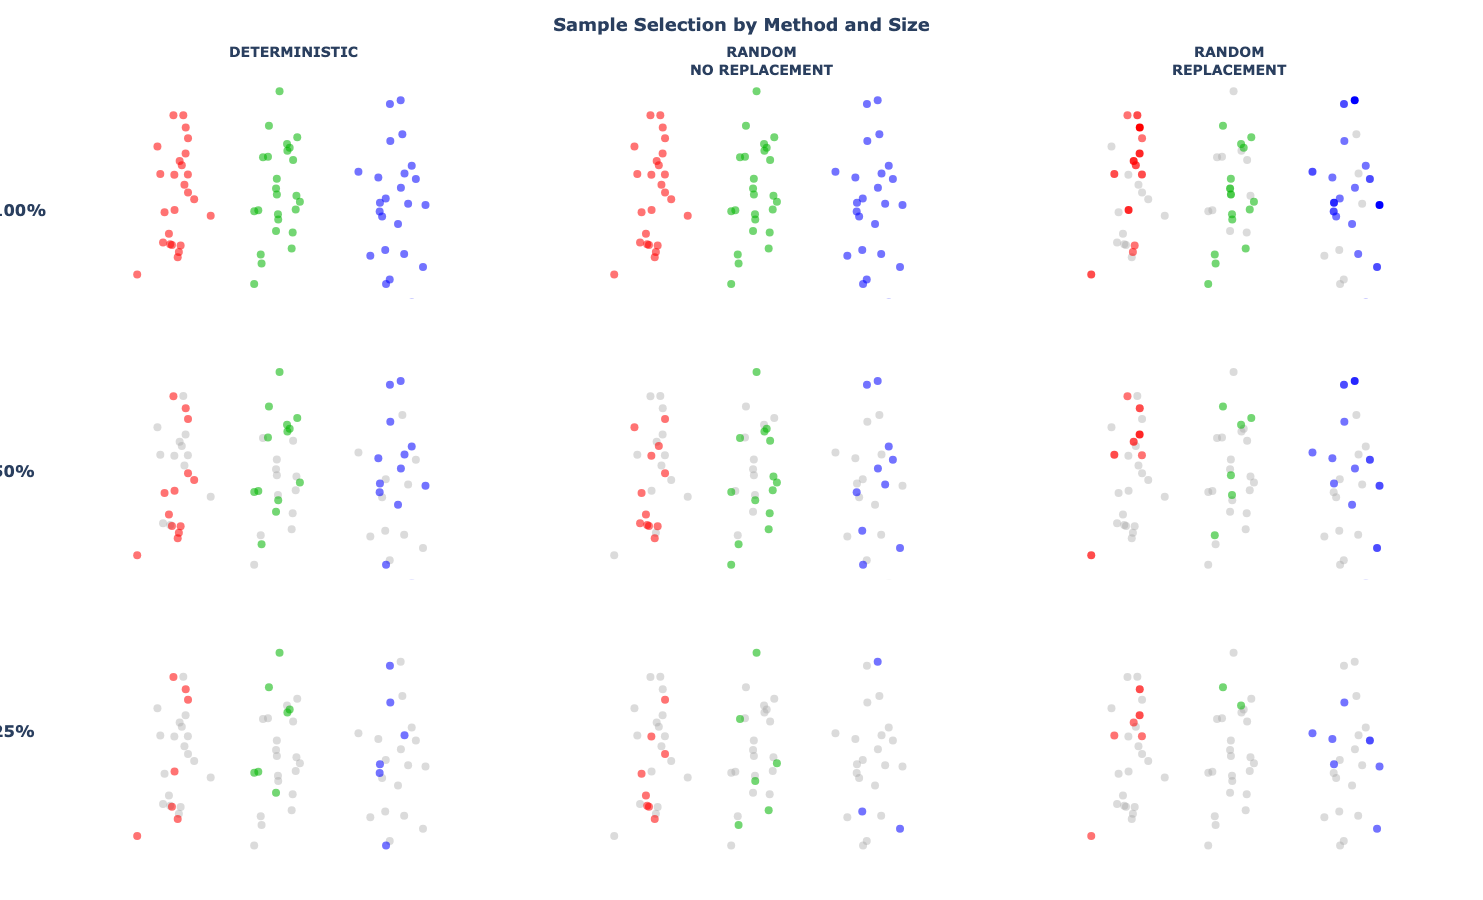

In [27]:
fig1.show()

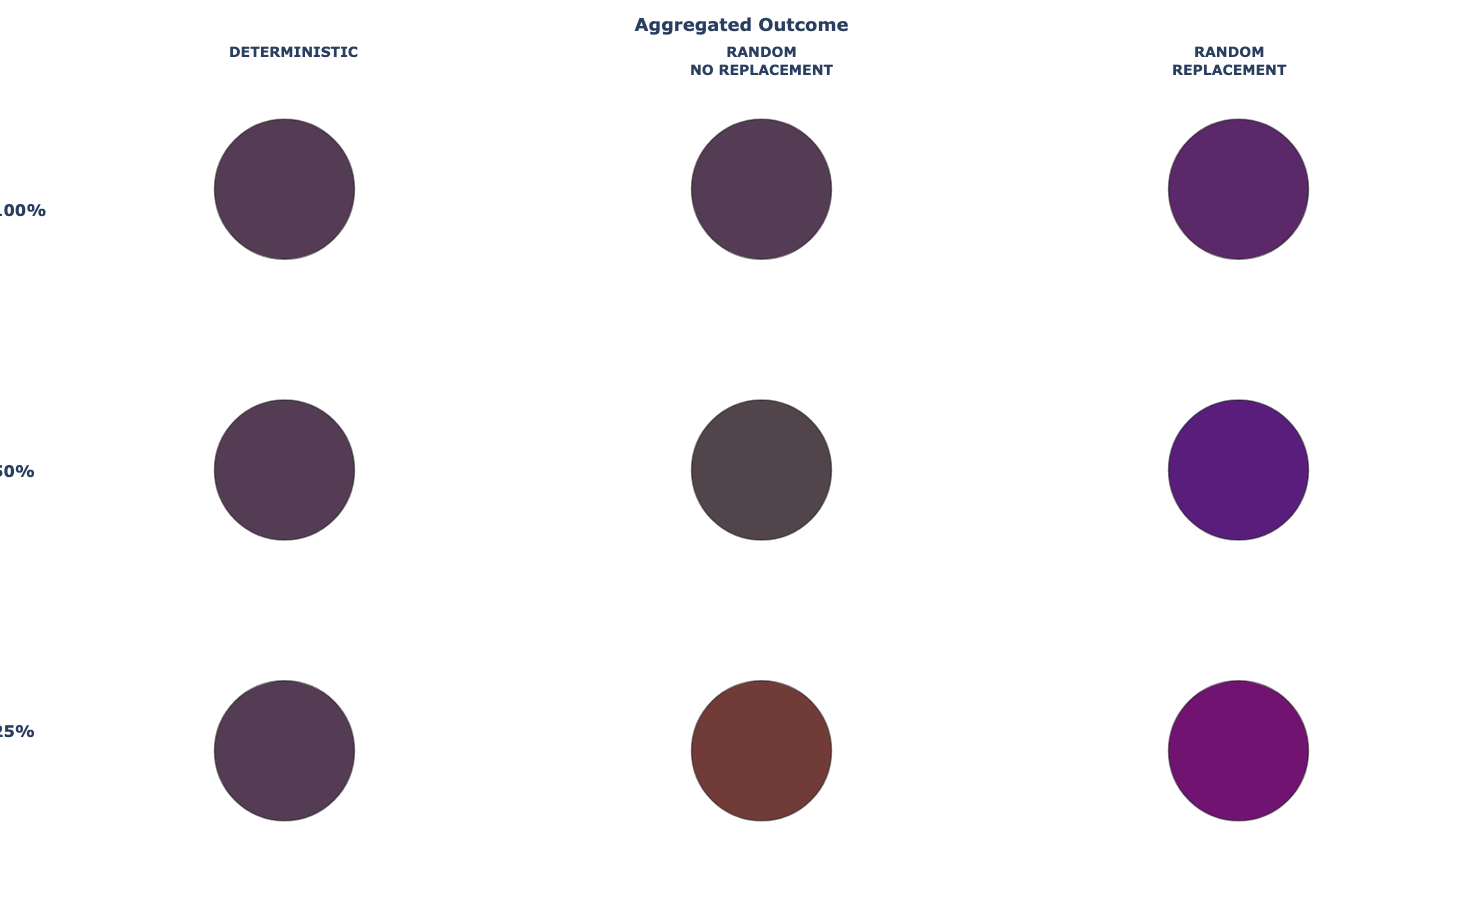

In [28]:
fig2.show()